# The Food Group — Incoming Call EDA

## MinneMUDAC 2026 | Undergraduate Division

### Dataset
Source: The Food Group
File: `Incoming Call.xlsx`

In [24]:
import sys
import re

# Data analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

# Visualization settings
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

# Environment information
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.13.14
Pandas version: 3.0.6
NumPy version: 2.5.3
Seaborn version: 0.13.2


In [25]:
# File path relative to the root project folder
call_path = "data/Incoming Call.xlsx"

# Read the Excel workbook
call_center_logs = pd.read_excel(call_path)

# Create a separate DataFrame for cleaning and EDA
df = call_center_logs.copy()

# Display basic information
print("Dataset loaded successfully.")
print(f"Rows: {call_center_logs.shape[0]:,}")
print(f"Columns: {call_center_logs.shape[1]}")

# Preview the first five records
display(call_center_logs.head())

Dataset loaded successfully.
Rows: 49,727
Columns: 31


,__ID,zzCreationTS,zzModificationTS,zzModificationTSNotServer,zzLastArchived,Date,TimeStamp,CallTime,CallLength,CallMethod,Call Answered,Call Description,BestContactMethod,County,Region,NumberInHouse,PrimaryReasonForCall,SNAP Status,BridgeToBenefitsScreen,Application Mailed,SNAPApplicationhelp,isSNAPRx,ReferralInfoEntry,Referral Source,HowHear,FollowUpNeeded,FollowUpNeededDays,Follow up Date,isFollowup1Complete,FollowupDate2,isFollowup2Complete
0,119284,2024-09-11T13:54:54Z,2026-02-13T12:47:16Z,NaN,2025-05-19T15:21:57Z,2024-09-11,2024-09-11T13:54:54Z,13:54:54,NaN,Email,NaN,Sent Text,NaN,( Out of State ),Unknown/Out Of State,4.00,Eligibility Requirements,NaN,NaN,NaN,NaN,NaN,UW-211,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
1,119285,2024-09-11T13:59:17Z,2026-02-13T12:47:16Z,NaN,2025-09-22T13:41:39Z,2024-09-11,2024-09-11T13:59:17Z,13:59:17,NaN,SNAP Rx,2nd,Sent Text,NaN,Kandiyohi,Southern Minnesota,1.00,SNAP Rx,Screened,NaN,NaN,NaN,1.00,SNAP Info Given\nMNBenefits\nFood Shelf,Southwest State University,NaN,Other,0.00,2024-09-13,1.00,NaT,NaN
2,119286,2024-09-11T14:09:22Z,2026-02-13T12:47:16Z,NaN,2025-09-22T13:41:39Z,2024-09-11,2024-09-11T14:09:22Z,14:09:22,NaN,Voice Mail,NaN,Sent Text,NaN,NaN,NaN,1.00,SUN Bucks,NaN,NaN,NaN,NaN,NaN,SUN Bucks Hotline,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
3,119287,2024-09-11T14:07:38Z,2026-02-13T12:47:16Z,NaN,2025-09-22T13:41:39Z,2024-09-11,2024-09-11T14:07:38Z,14:07:38,1-5 minutes,Chat Ticket,1st,NaN,NaN,(Unknown),Unknown/Out Of State,1.00,Other,Not Applicable,No,No,NaN,NaN,UW-211,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
4,119288,2024-09-11T14:09:54Z,2026-02-13T12:47:16Z,NaN,2025-05-19T15:21:57Z,2024-09-11,2024-09-11T14:09:54Z,14:09:54,1-5 minutes,Live Call,NaN,Sent Text,NaN,Hennepin,Twin Cities 7-Metro,1.00,Case-Specific Issues,Currently Enrolled,NaN,NaN,NaN,NaN,County Office,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN


In [26]:
# List columns and their data types
column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(column_info)

# Detailed dataset information
df.info()

# Numeric summary
display(df.describe(include=[np.number]).T)

# Categorical summary
display(
    df.describe(include=["object", "string"]).T
)

,Column,Data Type
0,__ID,int64
1,zzCreationTS,str
2,zzModificationTS,str
3,zzModificationTSNotServer,str
4,zzLastArchived,str
5,Date,datetime64[us]
6,TimeStamp,str
7,CallTime,object
8,CallLength,str
9,CallMethod,str


<class 'pandas.DataFrame'>
RangeIndex: 49727 entries, 0 to 49726
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   __ID                       49727 non-null  int64         
 1   zzCreationTS               49725 non-null  str           
 2   zzModificationTS           49727 non-null  str           
 3   zzModificationTSNotServer  7132 non-null   str           
 4   zzLastArchived             49727 non-null  str           
 5   Date                       49727 non-null  datetime64[us]
 6   TimeStamp                  49727 non-null  str           
 7   CallTime                   49202 non-null  object        
 8   CallLength                 28223 non-null  str           
 9   CallMethod                 49727 non-null  str           
 10  Call Answered              27057 non-null  str           
 11  Call Description           18782 non-null  str           
 12  BestContactMeth

,count,mean,std,min,25%,50%,75%,max
__ID,"49,727.00","118,269.59","14,386.03","81,356.00","105,830.50","118,263.00","130,693.50","143,662.00"
NumberInHouse,"49,710.00",1.22,0.77,1.00,1.00,1.00,1.00,14.00
isSNAPRx,"15,565.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00
FollowUpNeededDays,"14,002.00",0.39,2.43,0.00,0.00,0.00,0.00,42.00
isFollowup1Complete,"16,670.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00
isFollowup2Complete,874.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00


,count,unique,top,freq
zzCreationTS,49725,47314,2025-07-29T11:20:10Z,21
zzModificationTS,49727,418,2026-02-13T12:47:25Z,2000
zzModificationTSNotServer,7132,5961,2026-02-12T07:54:49Z,489
zzLastArchived,49727,2913,2026-02-12T08:06:22Z,1155
TimeStamp,49727,41439,2024-11-13T00:00:00Z,99
CallTime,49202,22390,00:00:00,8050
CallLength,28223,5,1-5 minutes,25947
CallMethod,49727,8,SNAP Rx,19096
Call Answered,27057,7,No Answer,13507
Call Description,18782,6,Left VM,7466


,Missing Count,Missing %,Non-Null Count
SNAPApplicationhelp,49702,99.95,25
FollowupDate2,49068,98.67,659
isFollowup2Complete,48853,98.24,874
HowHear,48652,97.84,1075
BestContactMethod,47154,94.83,2573
BridgeToBenefitsScreen,44890,90.27,4837
Application Mailed,44448,89.38,5279
zzModificationTSNotServer,42595,85.66,7132
FollowUpNeeded,35725,71.84,14002
FollowUpNeededDays,35725,71.84,14002


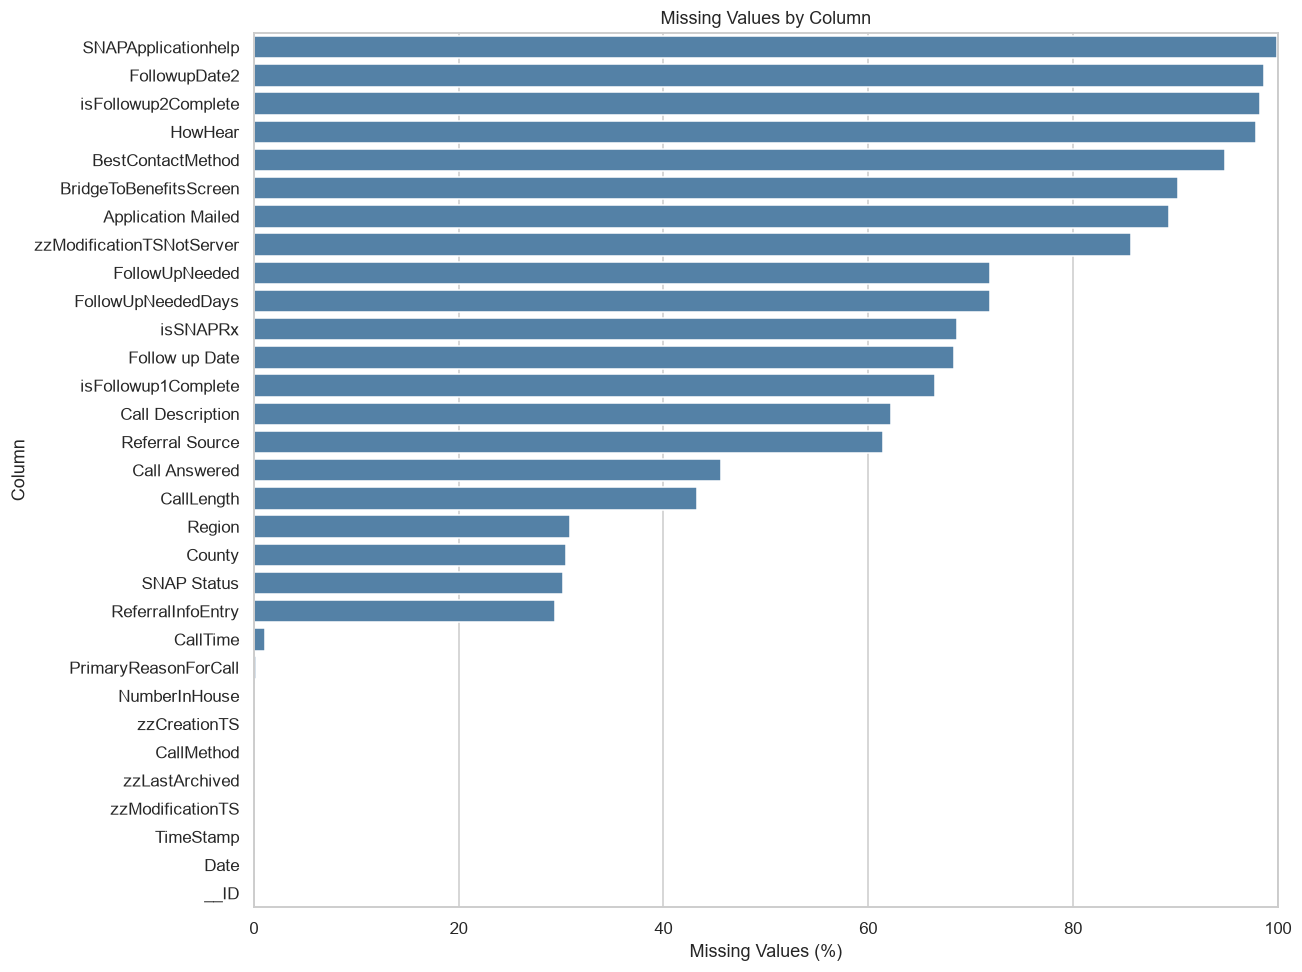

In [27]:
# Calculate missing-value statistics
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": df.isna().mean() * 100,
    "Non-Null Count": df.notna().sum()
})

missing_summary = missing_summary.sort_values(
    "Missing %",
    ascending=False
)

display(missing_summary.round(2))

# Visualize missing values
plt.figure(figsize=(12, 9))

sns.barplot(
    data=missing_summary.reset_index(),
    x="Missing %",
    y="index",
    color="steelblue"
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [28]:
# Check exact duplicate rows
exact_duplicates = df.duplicated().sum()

# Check repeated record identifiers
duplicate_ids = df.duplicated(
    subset=["__ID"]
).sum()

print(f"Exact duplicate rows: {exact_duplicates}")
print(f"Repeated record IDs: {duplicate_ids}")

# Examine all records with repeated IDs
duplicate_records = df.loc[
    df.duplicated(
        subset=["__ID"],
        keep=False
    ),
    [
        "__ID",
        "Date",
        "CallMethod",
        "PrimaryReasonForCall"
    ]
].sort_values("__ID")

display(duplicate_records)

Exact duplicate rows: 1
Repeated record IDs: 2


,__ID,Date,CallMethod,PrimaryReasonForCall
49726,92278,2022-11-23,SNAP Rx,SNAP Rx
49693,92278,2022-11-23,SNAP Rx,SNAP Rx
1542,120501,2024-09-03,SNAP Rx,SNAP Rx
1509,120501,2024-09-03,SNAP Rx,SNAP Rx


In [29]:
# Remove only completely identical records
df = df.drop_duplicates().copy()

print(
    "Records remaining after exact duplicate removal:",
    len(df)
)

Records remaining after exact duplicate removal: 49726


In [30]:
# Inspect original date values
display(df["Date"].head(10))

print("Original Date dtype:", df["Date"].dtype)

# Excel dates may be numeric serial dates or datetime values
if pd.api.types.is_numeric_dtype(df["Date"]):

    df["contact_date"] = pd.to_datetime(
        df["Date"],
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )

else:

    df["contact_date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

# Parse the system timestamp separately
df["event_timestamp_utc"] = pd.to_datetime(
    df["TimeStamp"],
    errors="coerce",
    utc=True
)

# Create time-based analysis fields
df["year"] = df["contact_date"].dt.year

df["month_num"] = df["contact_date"].dt.month

df["month_name"] = df["contact_date"].dt.strftime("%b")

df["year_month"] = df["contact_date"].dt.to_period("M")

# Date validation
print("Earliest contact:", df["contact_date"].min())
print("Latest contact:", df["contact_date"].max())

print(
    "Missing or invalid contact dates:",
    df["contact_date"].isna().sum()
)

# Count records by year
display(
    df.groupby("year", dropna=False)
      .size()
      .rename("Contacts")
      .to_frame()
)

0   2024-09-11
1   2024-09-11
2   2024-09-11
3   2024-09-11
4   2024-09-11
5   2024-09-11
6   2024-09-11
7   2024-09-11
8   2024-09-11
9   2024-09-11
Name: Date, dtype: datetime64[us]

Original Date dtype: datetime64[us]
Earliest contact: 2022-02-23 00:00:00
Latest contact: 2026-07-31 00:00:00
Missing or invalid contact dates: 0


,Contacts
year,
2022,41
2023,15434
2024,14599
2025,12590
2026,7062


In [31]:
# Identify categorical columns for initial cleaning
category_columns = [
    "CallMethod",
    "Call Answered",
    "CallLength",
    "County",
    "Region",
    "PrimaryReasonForCall",
    "SNAP Status",
    "Referral Source",
    "FollowUpNeeded"
]

# Remove leading/trailing whitespace
# and convert empty strings to missing values
for col in category_columns:

    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# Normalize known equivalent answer labels
df["call_answered_clean"] = (
    df["Call Answered"].replace({
        "1st Call": "1st",
        "2nd Call": "2nd"
    })
)

# Summarize categorical variables
category_summary = pd.DataFrame({
    "Unique Values": df[category_columns].nunique(),
    "Missing %": (
        df[category_columns].isna().mean() * 100
    )
})

display(category_summary.round(2))

# Inspect key categories
for col in [
    "CallMethod",
    "Call Answered",
    "PrimaryReasonForCall",
    "SNAP Status"
]:

    print(f"\n{col}")

    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("Count")
    )

,Unique Values,Missing %
CallMethod,8,0.00
Call Answered,7,45.59
CallLength,5,43.24
County,115,30.49
Region,5,30.83
PrimaryReasonForCall,32,0.20
SNAP Status,12,30.16
Referral Source,150,61.41
FollowUpNeeded,5,71.84



CallMethod


,Count
CallMethod,
SNAP Rx,19095
Live Call,17359
Voice Mail,7347
Email,4193
Chat Ticket,1048
Chat,374
Text,200
Partner Referral,110



Call Answered


,Count
Call Answered,
<NA>,22670
No Answer,13506
1st,8817
2nd,4099
3rd,553
4th,66
1st Call,12
2nd Call,3



PrimaryReasonForCall


,Count
PrimaryReasonForCall,
SNAP Rx,19093
Food Shelf,8108
Case-Specific Issues,4686
Eligibility Requirements,3356
Other,2679
EBT Card,2450
SUN Bucks,1812
Application Status,1602
Application Assistance,1231



SNAP Status


,Count
SNAP Status,
<NA>,14998
Currently Enrolled,8252
Not Reached,5147
Materials Provided,5142
Screened-Eligible,4421
Applied,3694
Screened,3042
Not Applicable,2723
Screened-Not Eligible,1232


,year,contacts
0,2022,41
1,2023,15434
2,2024,14599
3,2025,12590
4,2026,7062


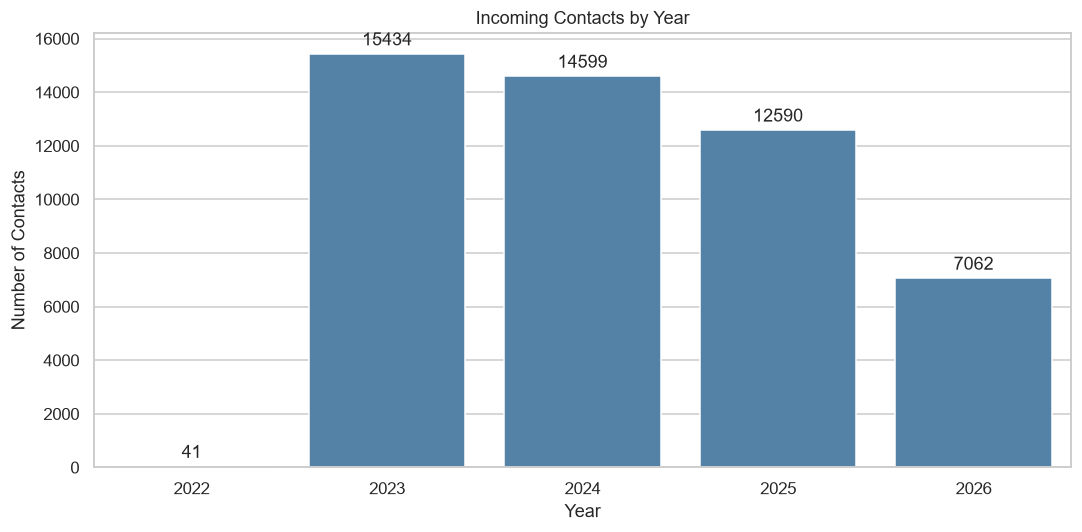

In [32]:
# Calculate contacts by year
yearly_contacts = (
    df.groupby("year")
      .size()
      .reset_index(name="contacts")
)

display(yearly_contacts)

# Visualize annual counts
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=yearly_contacts,
    x="year",
    y="contacts",
    color="steelblue"
)

# Add value labels
ax.bar_label(
    ax.containers[0],
    fmt="%d",
    padding=3
)

plt.title("Incoming Contacts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Contacts")

plt.tight_layout()
plt.show()

,contact_date,contacts
0,2022-02-01,1
1,2022-03-01,5
2,2022-04-01,4
3,2022-05-01,2
4,2022-06-01,2
5,2022-07-01,7
6,2022-08-01,5
7,2022-09-01,2
8,2022-10-01,3
9,2022-11-01,6


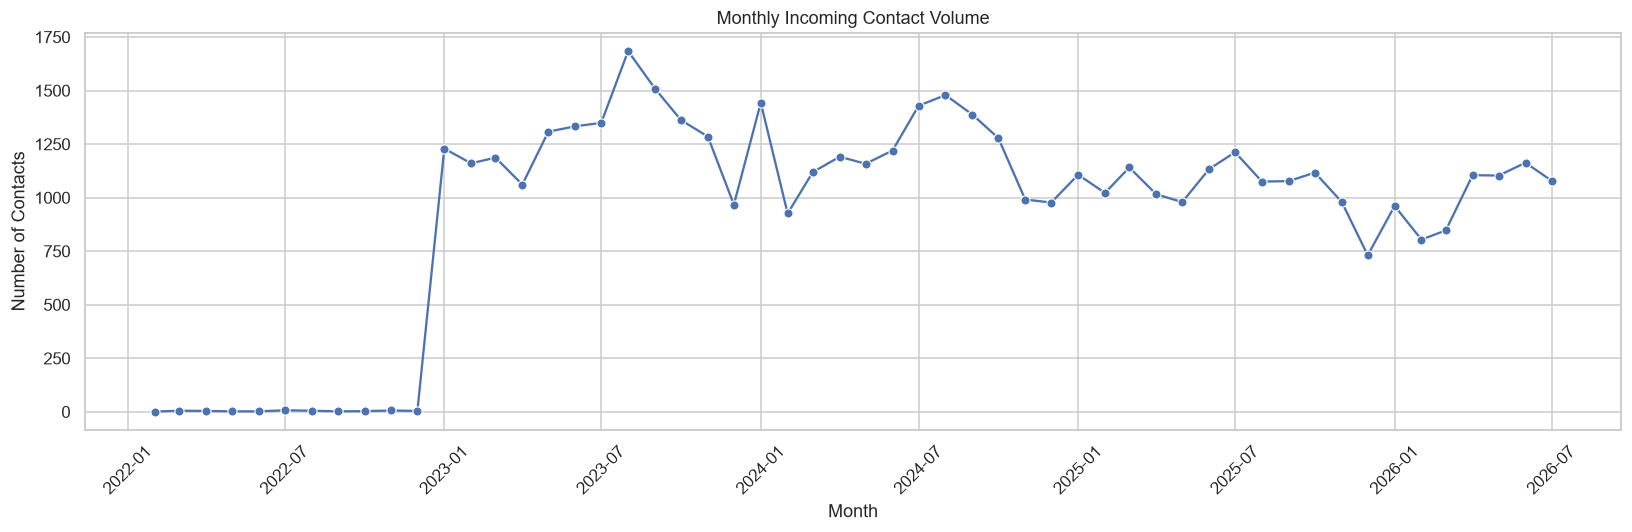

In [33]:
# Aggregate records by calendar month
monthly_contacts = (
    df.dropna(subset=["contact_date"])
      .set_index("contact_date")
      .resample("MS")
      .size()
      .rename("contacts")
      .reset_index()
)

display(monthly_contacts.head(12))

# Plot monthly trends
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_contacts,
    x="contact_date",
    y="contacts",
    marker="o"
)

plt.title("Monthly Incoming Contact Volume")
plt.xlabel("Month")
plt.ylabel("Number of Contacts")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2023,1229,1160,1187,1061,1308,1333,1349,1684,1509,1362,1285,967
2024,1443,926,1119,1191,1158,1220,1429,1479,1388,1278,991,977
2025,1107,1022,1141,1016,979,1133,1212,1075,1077,1117,980,731


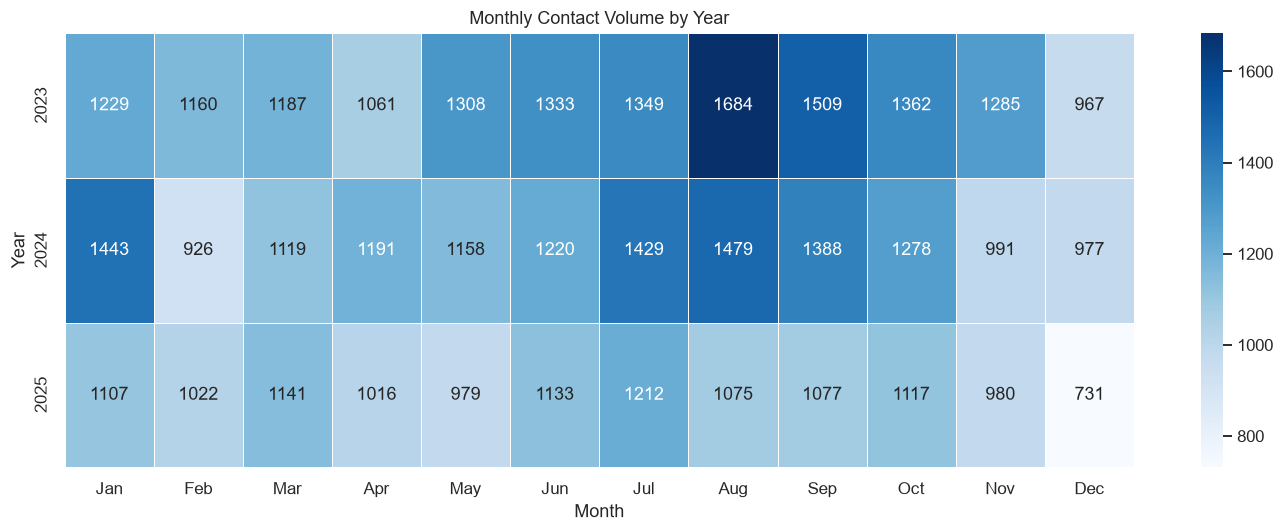

In [34]:
# Use complete calendar years for seasonality
complete_years = df[
    df["year"].isin([2023, 2024, 2025])
].copy()

# Calculate monthly counts for each year
monthly_matrix = pd.crosstab(
    complete_years["year"],
    complete_years["month_num"]
).reindex(
    columns=range(1, 13),
    fill_value=0
)

monthly_matrix.columns = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

display(monthly_matrix)

# Heatmap
plt.figure(figsize=(13, 5))

sns.heatmap(
    monthly_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Monthly Contact Volume by Year")
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

,CallMethod,contacts
0,SNAP Rx,19095
1,Live Call,17359
2,Voice Mail,7347
3,Email,4193
4,Chat Ticket,1048
5,Chat,374
6,Text,200
7,Partner Referral,110


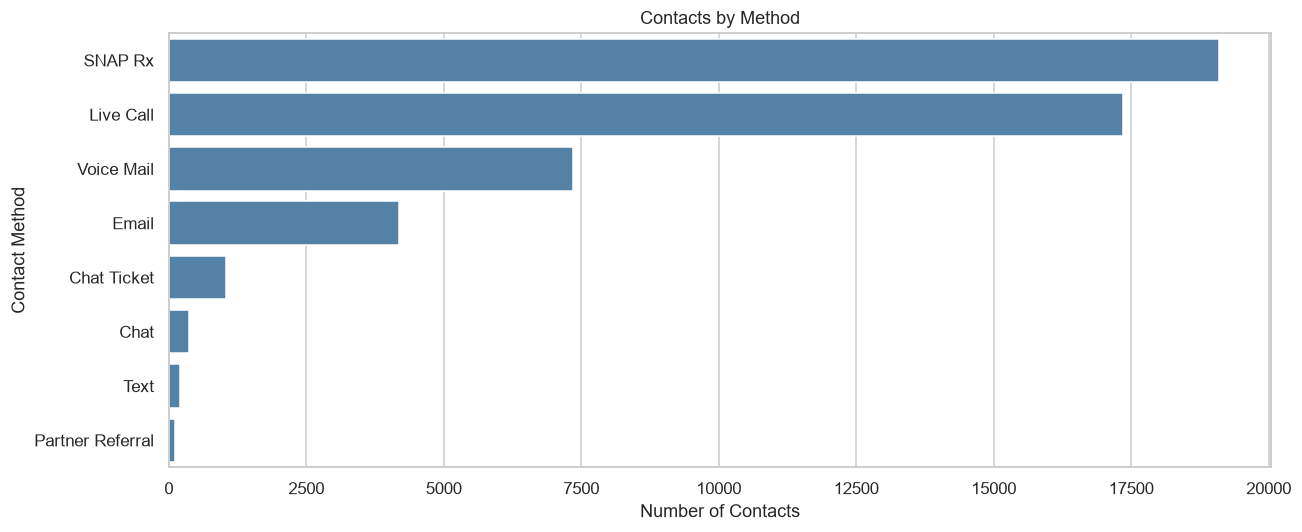

In [35]:
# Frequency of each contact method
method_counts = (
    df["CallMethod"]
    .value_counts(dropna=False)
    .rename_axis("CallMethod")
    .reset_index(name="contacts")
)

display(method_counts)

# Visualize methods
plt.figure(figsize=(12, 5))

sns.barplot(
    data=method_counts,
    x="contacts",
    y="CallMethod",
    color="steelblue"
)

plt.title("Contacts by Method")
plt.xlabel("Number of Contacts")
plt.ylabel("Contact Method")

plt.tight_layout()
plt.show()

CallMethod,Chat,Chat Ticket,Email,Live Call,Partner Referral,SNAP Rx,Text,Voice Mail
year,,,,,,,,
2022,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00
2023,0.87,3.67,8.84,41.73,0.40,25.45,0.14,18.90
2024,0.61,3.23,9.70,35.91,0.28,30.84,0.55,18.88
2025,1.06,0.08,7.95,27.92,0.00,52.52,0.44,10.02
2026,0.23,0.00,5.83,30.61,0.10,56.80,0.61,5.82


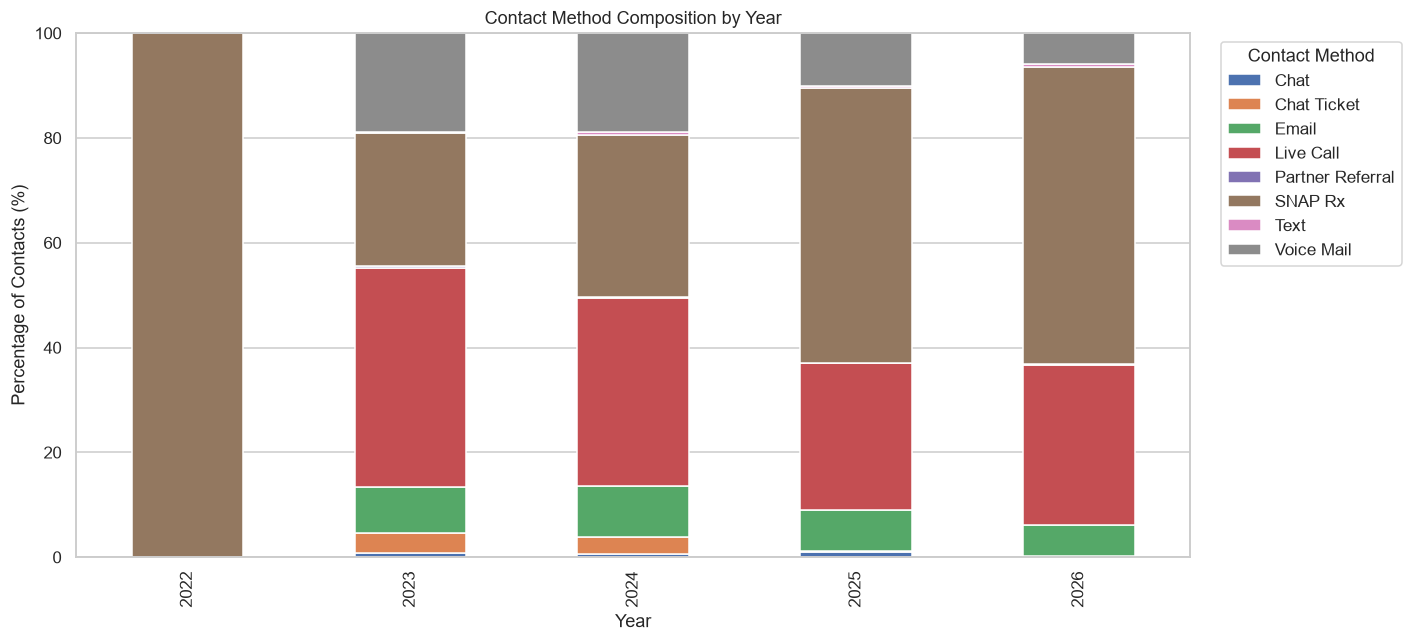

In [36]:
# Contact method shares by year
method_year = pd.crosstab(
    df["year"],
    df["CallMethod"],
    normalize="index"
) * 100

display(method_year.round(2))

# Stacked bar chart
method_year.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6)
)

plt.title("Contact Method Composition by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Contacts (%)")

plt.legend(
    title="Contact Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

,Reason,contacts,percent
0,SNAP Rx,19093,38.40
1,Food Shelf,8108,16.31
2,Case-Specific Issues,4686,9.42
3,Eligibility Requirements,3356,6.75
4,Other,2679,5.39
5,EBT Card,2450,4.93
6,SUN Bucks,1812,3.64
7,Application Status,1602,3.22
8,Application Assistance,1231,2.48
9,Unknown,1043,2.10


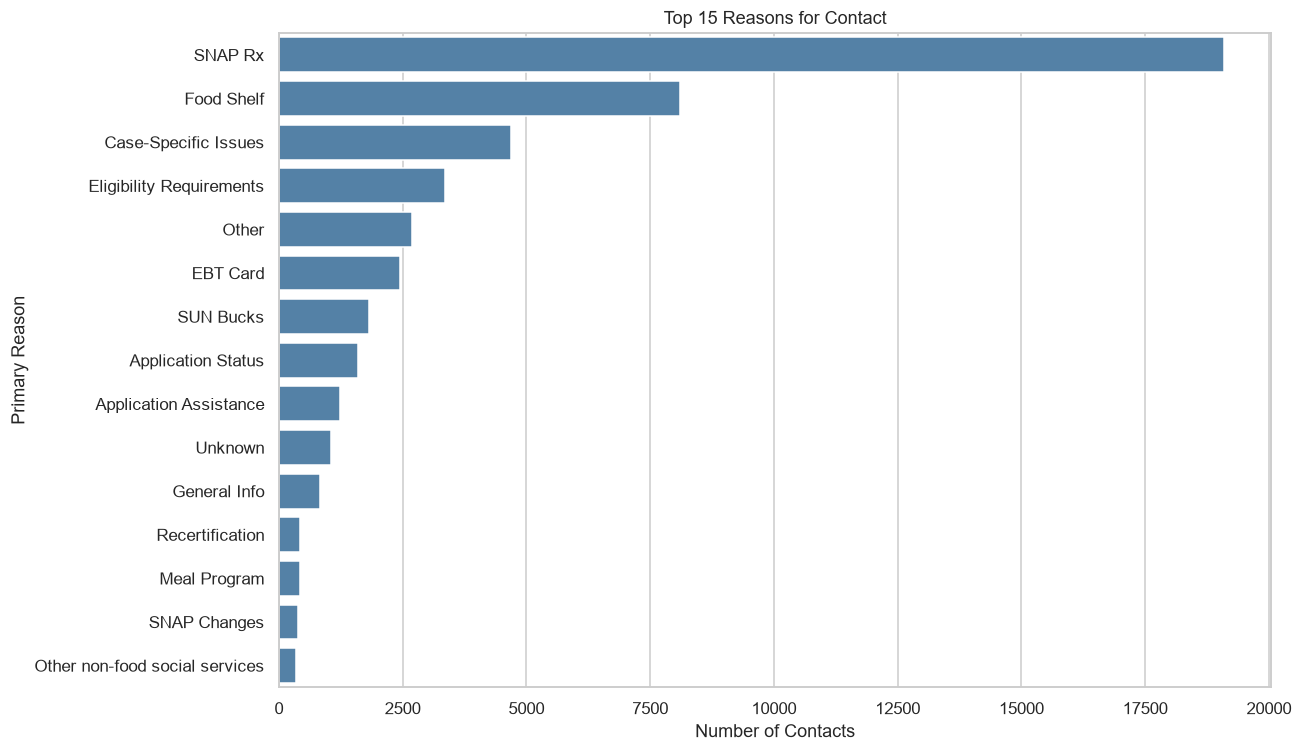

In [37]:
# Count contact reasons
reason_counts = (
    df["PrimaryReasonForCall"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="contacts")
)

# Calculate percentages
reason_counts["percent"] = (
    reason_counts["contacts"] / len(df) * 100
)

display(reason_counts)

# Plot the 15 most common reasons
plt.figure(figsize=(12, 7))

sns.barplot(
    data=reason_counts.head(15),
    x="contacts",
    y="Reason",
    color="steelblue"
)

plt.title("Top 15 Reasons for Contact")
plt.xlabel("Number of Contacts")
plt.ylabel("Primary Reason")

plt.tight_layout()
plt.show()

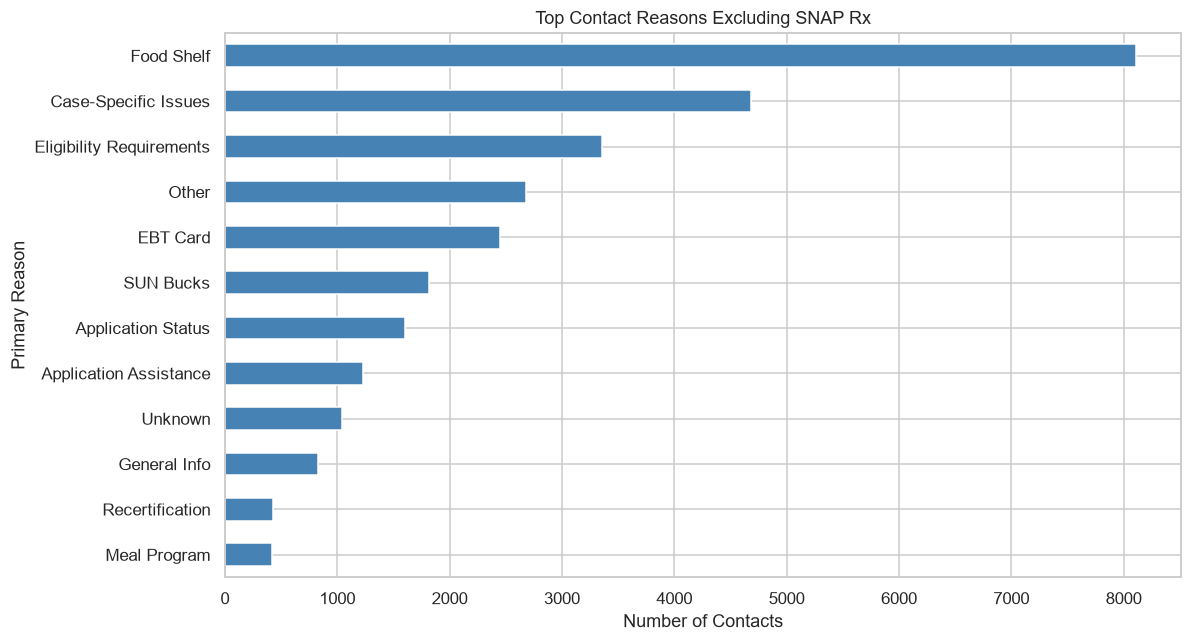

In [38]:
# Remove SNAP Rx from this supplementary analysis
non_snap_rx = df[
    df["PrimaryReasonForCall"] != "SNAP Rx"
].copy()

# Count other reasons
top_other_reasons = (
    non_snap_rx["PrimaryReasonForCall"]
    .value_counts()
    .head(12)
    .sort_values()
)

# Plot
plt.figure(figsize=(11, 6))

top_other_reasons.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top Contact Reasons Excluding SNAP Rx")
plt.xlabel("Number of Contacts")
plt.ylabel("Primary Reason")

plt.tight_layout()
plt.show()

PrimaryReasonForCall,SNAP Rx,Food Shelf,Case-Specific Issues,Eligibility Requirements,Other,EBT Card,SUN Bucks,Application Status,Application Assistance,Unknown
CallMethod,,,,,,,,,,
Chat,0.00,35.83,2.94,6.68,18.72,2.41,12.83,1.34,4.01,0.80
Chat Ticket,0.00,37.31,4.77,7.54,15.36,1.53,19.85,0.67,4.77,0.00
Email,0.00,55.56,2.22,9.98,13.39,1.12,6.37,0.60,2.22,0.72
Live Call,0.00,20.12,20.23,10.62,4.86,11.36,5.97,6.70,4.60,3.74
Partner Referral,0.00,3.64,1.82,14.55,26.36,0.00,0.00,0.91,50.00,1.82
SNAP Rx,99.99,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
Text,0.00,49.50,3.50,11.00,8.00,0.50,1.50,6.00,2.50,3.00
Voice Mail,0.00,22.85,14.03,13.10,13.65,5.65,3.49,5.38,2.97,4.85


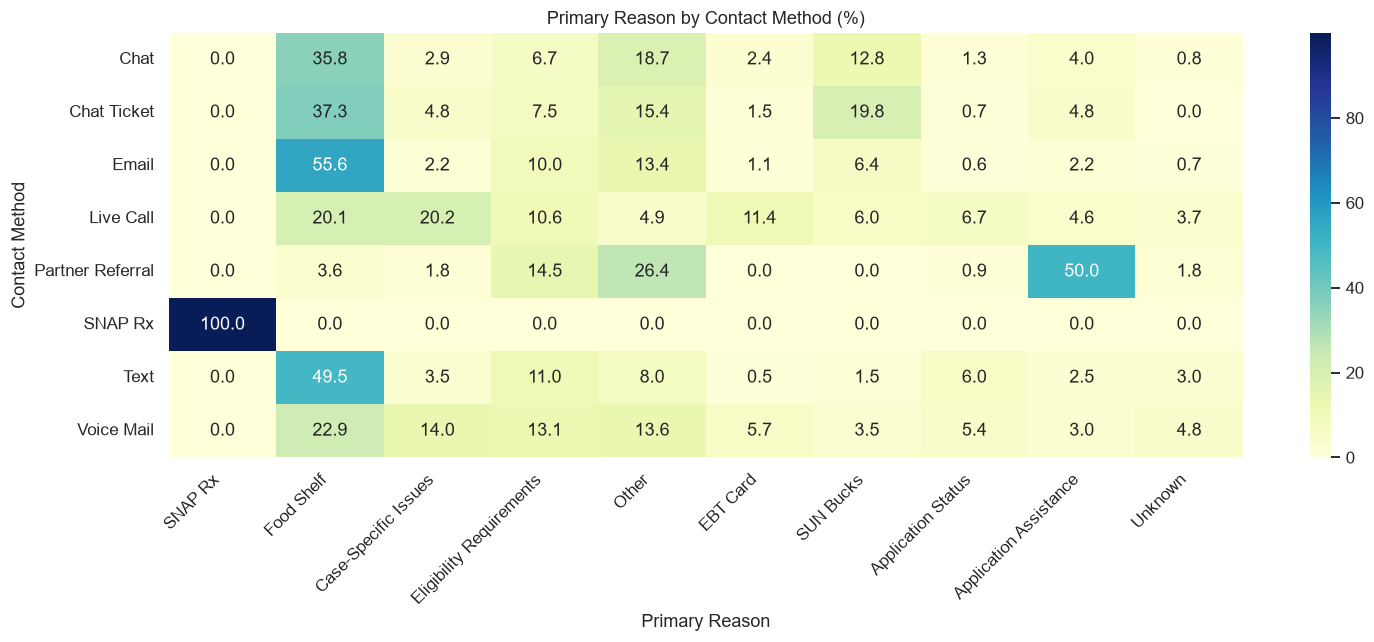

In [39]:
# Create method-by-reason frequency table
method_reason = pd.crosstab(
    df["CallMethod"],
    df["PrimaryReasonForCall"]
)

# Identify the ten most frequent reasons
top_reasons = (
    df["PrimaryReasonForCall"]
    .value_counts()
    .head(10)
    .index
)

method_reason_top = method_reason.reindex(
    columns=top_reasons,
    fill_value=0
)

# Convert to percentages within each contact method
method_reason_pct = (
    method_reason_top.div(
        method_reason.sum(axis=1),
        axis=0
    ) * 100
)

display(method_reason_pct.round(2))

# Heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    method_reason_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title(
    "Primary Reason by Contact Method (%)"
)

plt.xlabel("Primary Reason")
plt.ylabel("Contact Method")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [40]:
# Preserve original county information
df["county_original"] = df["County"].copy()

# Create a cleaned county field
df["county_clean"] = (
    df["County"]
    .astype("string")
    .str.strip()
)

# Standardize known county naming differences
county_map = {
    "Hennepin-Suburbs": "Hennepin",
    "Minneapolis": "Hennepin",
    "Ramsey-Suburbs": "Ramsey",
    "Saint Paul": "Ramsey",
    "St. Paul": "Ramsey",
    "Saint Louis": "St. Louis"
}

df["county_clean"] = (
    df["county_clean"]
    .replace(county_map)
)

# Flag clearly unknown or out-of-state entries
invalid_county_pattern = (
    r"(?i)unknown|out\s*of\s*state|not provided"
)

df["county_flagged"] = (
    df["county_clean"].isna()
    | df["county_clean"].str.contains(
        invalid_county_pattern,
        regex=True,
        na=False
    )
)

df["county_for_analysis"] = (
    df["county_clean"]
    .mask(df["county_flagged"])
)

# Examine remaining geographic coverage
print(
    "Distinct county labels:",
    df["county_for_analysis"].nunique()
)

print(
    "Missing or flagged counties:",
    df["county_for_analysis"].isna().sum()
)

display(
    df["county_clean"]
    .value_counts(dropna=False)
    .head(30)
)

Distinct county labels: 110
Missing or flagged counties: 16973


county_clean
<NA>                    15159
Hennepin                12723
Ramsey                  10570
Dakota                   2135
Anoka                    1483
(Unknown)                1106
Washington                794
( Out of State )          708
St. Louis                 571
Stearns                   481
Scott                     398
Wright                    374
Olmsted                   224
Carver                    168
Sherburne                 167
Hennepin-Minneapolis      149
Itasca                    116
Ramsey-Saint Paul         103
Crow Wing                  92
Chisago                    92
Clay                       89
Cass                       82
Rice                       75
Isanti                     74
Blue Earth                 72
Carlton                    72
Beltrami                   71
Goodhue                    63
Steele                     59
Winona                     57
Name: count, dtype: Int64

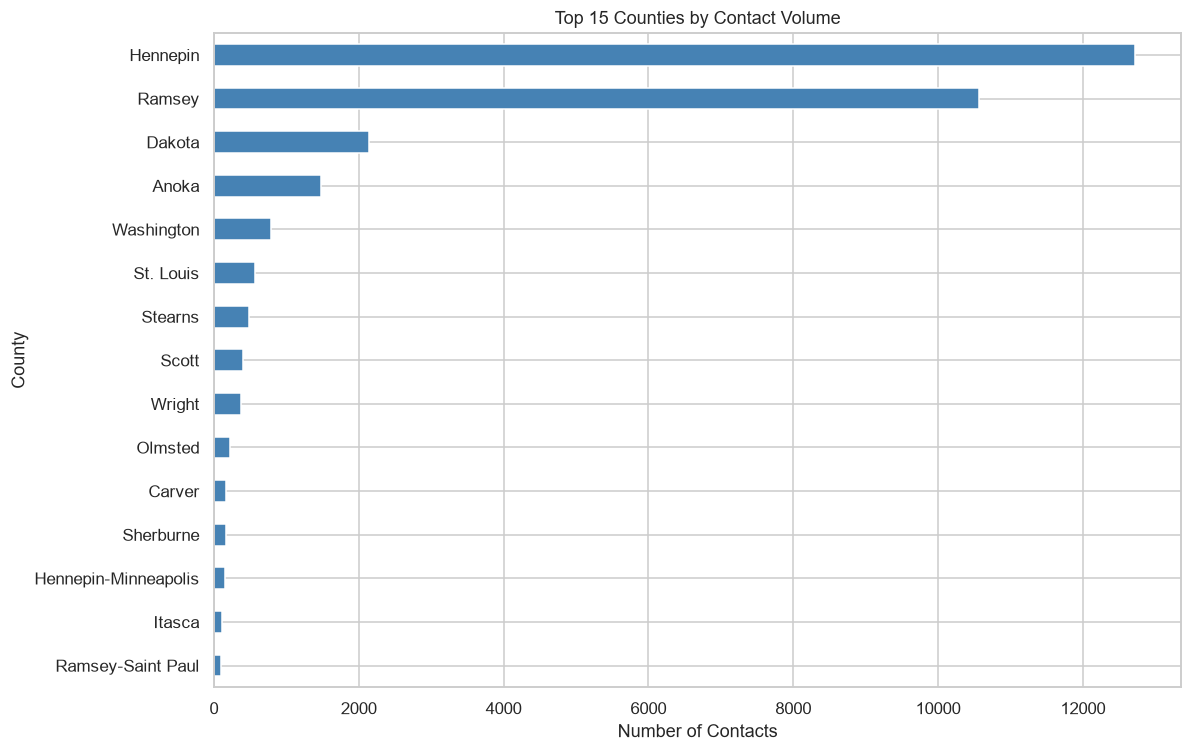

Usable county coverage: 65.87%


In [41]:
# Count contacts by county
county_counts = (
    df["county_for_analysis"]
    .value_counts()
    .head(15)
    .sort_values()
)

# Plot
plt.figure(figsize=(11, 7))

county_counts.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 15 Counties by Contact Volume")
plt.xlabel("Number of Contacts")
plt.ylabel("County")

plt.tight_layout()
plt.show()

# Calculate geographic coverage
county_coverage = (
    df["county_for_analysis"].notna().mean() * 100
)

print(
    f"Usable county coverage: {county_coverage:.2f}%"
)

,Contacts
call_answered_clean,
<NA>,22670
No Answer,13506
1st,8829
2nd,4102
3rd,553
4th,66


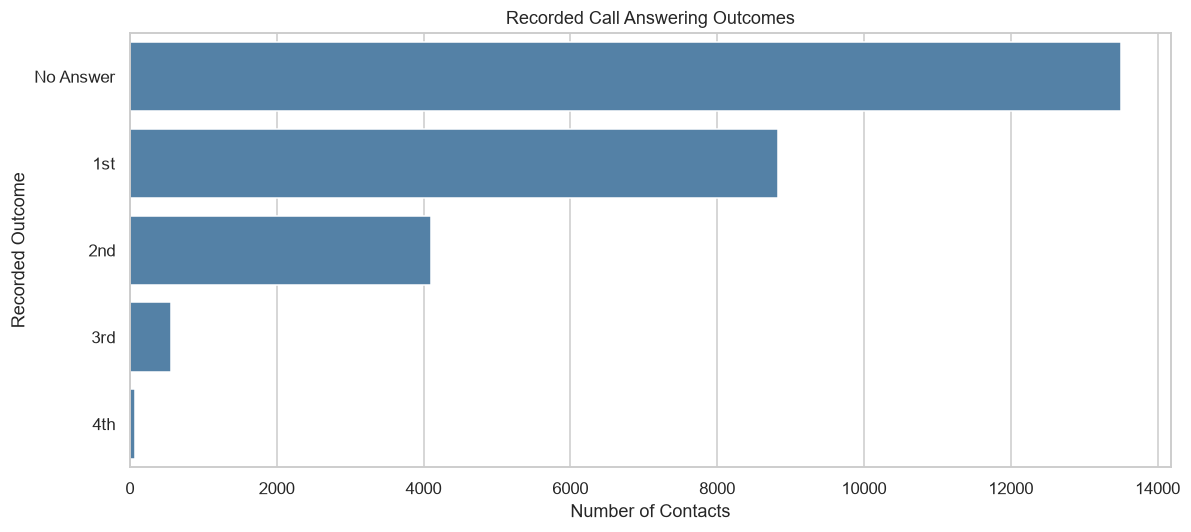

In [42]:
# Count recorded answering outcomes
answered_counts = (
    df["call_answered_clean"]
    .value_counts(dropna=False)
)

display(
    answered_counts.to_frame("Contacts")
)

plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    y="call_answered_clean",
    order=(
        df["call_answered_clean"]
        .value_counts()
        .index
    ),
    color="steelblue"
)

plt.title("Recorded Call Answering Outcomes")
plt.xlabel("Number of Contacts")
plt.ylabel("Recorded Outcome")

plt.tight_layout()
plt.show()

In [43]:
# Examine how frequently answer information is recorded
answered_by_method = (
    df.groupby("CallMethod")["call_answered_clean"]
    .agg(
        records="size",
        recorded="count"
    )
)

answered_by_method["recorded_pct"] = (
    answered_by_method["recorded"]
    / answered_by_method["records"] * 100
)

display(answered_by_method.round(2))


,records,recorded,recorded_pct
CallMethod,,,
Chat,374,31,8.29
Chat Ticket,1048,113,10.78
Email,4193,1215,28.98
Live Call,17359,1813,10.44
Partner Referral,110,95,86.36
SNAP Rx,19095,19092,99.98
Text,200,18,9.00
Voice Mail,7347,4679,63.69


,Contacts
SNAP Status,
<NA>,14998
Currently Enrolled,8252
Not Reached,5147
Materials Provided,5142
Screened-Eligible,4421
Applied,3694
Screened,3042
Not Applicable,2723
Screened-Not Eligible,1232


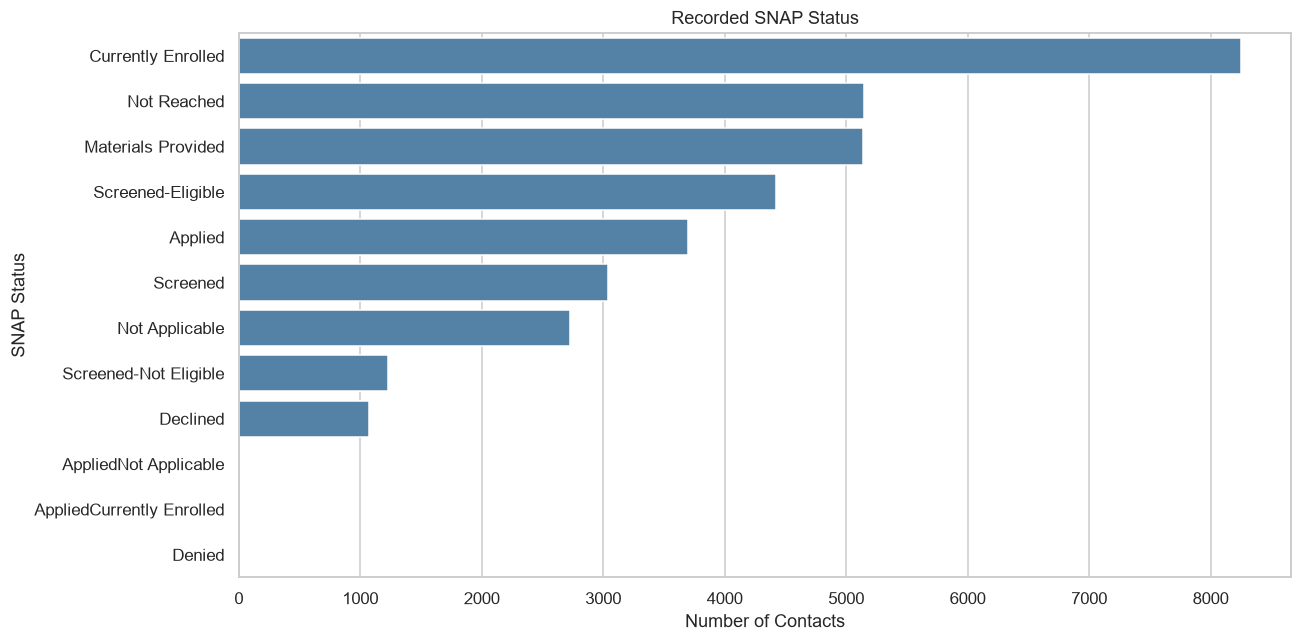

In [44]:
# Count SNAP status categories
snap_status = (
    df["SNAP Status"]
    .value_counts(dropna=False)
)

display(
    snap_status.to_frame("Contacts")
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    x=snap_status.values,
    y=snap_status.index.astype(str),
    color="steelblue"
)

plt.title("Recorded SNAP Status")
plt.xlabel("Number of Contacts")
plt.ylabel("SNAP Status")

plt.tight_layout()
plt.show()


SNAP Status,Applied,AppliedCurrently Enrolled,AppliedNot Applicable,Currently Enrolled,Declined,Materials Provided,Not Applicable,Not Reached,Screened,Screened-Eligible,Screened-Not Eligible
PrimaryReasonForCall,,,,,,,,,,,
Application Status,94.99,0.00,0.00,2.81,0.00,0.53,0.70,0.00,0.09,0.79,0.09
Case-Specific Issues,24.43,0.03,0.00,67.96,0.03,2.29,4.44,0.30,0.05,0.40,0.08
EBT Card,0.70,0.00,0.00,96.04,0.00,2.09,1.07,0.11,0.00,0.00,0.00
Eligibility Requirements,2.13,0.00,0.00,1.35,0.11,3.18,4.82,0.30,15.66,60.45,12.00
Food Shelf,9.75,0.00,0.00,18.97,0.52,13.24,39.43,0.93,11.16,3.94,2.05
Other,3.83,0.00,0.00,28.16,0.00,1.15,20.69,0.38,36.97,6.70,2.11
SNAP Rx,5.08,0.00,0.00,10.89,5.45,23.15,1.21,26.63,10.60,12.65,4.33
SUN Bucks,0.23,0.00,0.23,11.40,0.23,10.70,73.49,0.00,1.40,2.33,0.00


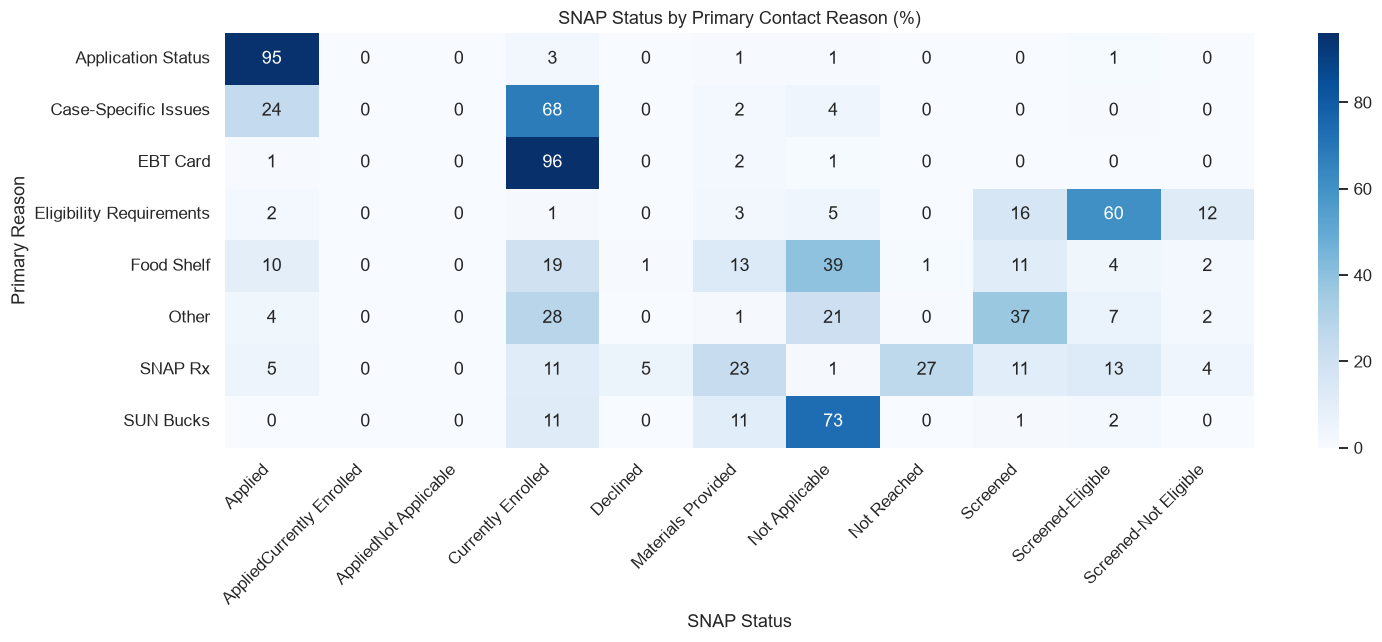

In [45]:
# Identify the most frequent contact reasons
top_reasons = (
    df["PrimaryReasonForCall"]
    .value_counts()
    .head(8)
    .index
)

# Filter to those reasons
snap_reason_data = df[
    df["PrimaryReasonForCall"].isin(top_reasons)
].copy()

# Calculate SNAP status percentages by reason
snap_reason_table = pd.crosstab(
    snap_reason_data["PrimaryReasonForCall"],
    snap_reason_data["SNAP Status"],
    normalize="index"
) * 100

display(snap_reason_table.round(2))

# Plot
plt.figure(figsize=(14, 6))

sns.heatmap(
    snap_reason_table,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("SNAP Status by Primary Contact Reason (%)")
plt.xlabel("SNAP Status")
plt.ylabel("Primary Reason")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

,Occurrences
resource,
Food Shelf,17194
SNAP Info Given,13552
MNBenefits,13189
County Office,7882
Meal Program,4758
Fare For All,3417
UW-211,2965
EBT Edge Service Center,2675
Farmers Market,2402


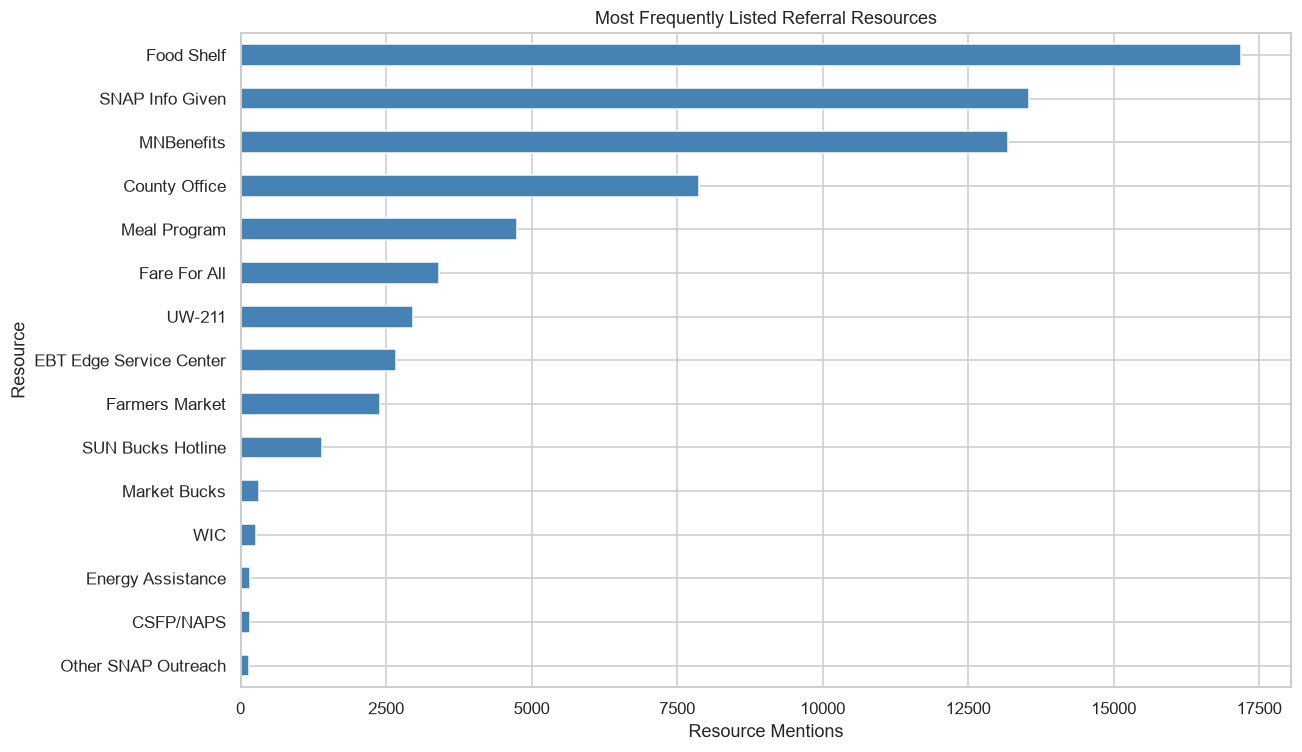

In [46]:
# Select records containing referral information
referrals = df[
    ["__ID", "contact_date", "ReferralInfoEntry"]
].dropna(
    subset=["ReferralInfoEntry"]
).copy()

# Split multiline referral entries
referrals["resource"] = (
    referrals["ReferralInfoEntry"]
    .astype("string")
    .str.split(r"\r?\n")
)

# Create one row per resource mention
referrals = referrals.explode("resource")

# Clean resource text
referrals["resource"] = (
    referrals["resource"]
    .astype("string")
    .str.strip()
)

# Remove empty entries
referrals = referrals[
    referrals["resource"].notna()
    & referrals["resource"].ne("")
].copy()

# Count resources
resource_counts = (
    referrals["resource"]
    .value_counts()
)

display(
    resource_counts.head(20).to_frame("Occurrences")
)

# Visualize frequent resources
plt.figure(figsize=(12, 7))

resource_counts.head(15).sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Most Frequently Listed Referral Resources")
plt.xlabel("Resource Mentions")
plt.ylabel("Resource")

plt.tight_layout()
plt.show()

count   35,114.00
mean         2.02
std          1.31
min          1.00
25%          1.00
50%          1.00
75%          3.00
max          9.00
Name: resource_count, dtype: float64

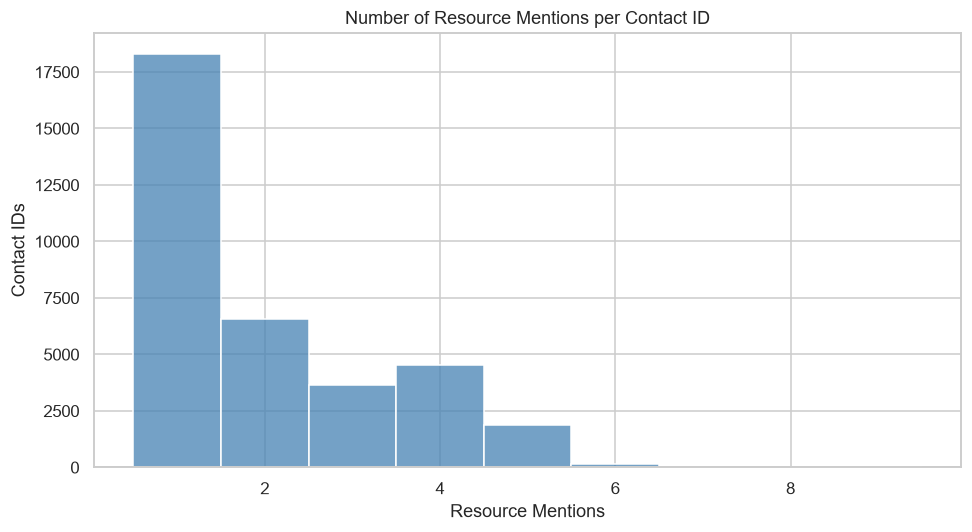

In [47]:
# Count resource mentions per record identifier
resources_per_contact = (
    referrals.groupby("__ID")
    .size()
    .rename("resource_count")
)

display(resources_per_contact.describe())

# Distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    resources_per_contact,
    discrete=True,
    color="steelblue"
)

plt.title("Number of Resource Mentions per Contact ID")
plt.xlabel("Resource Mentions")
plt.ylabel("Contact IDs")

plt.tight_layout()
plt.show()

In [48]:
# Primary reason indicates Food Shelf
df["food_shelf_reason"] = (
    df["PrimaryReasonForCall"]
    .eq("Food Shelf")
    .fillna(False)
)

# Food Shelf appears in referral information
df["food_shelf_referral"] = (
    df["ReferralInfoEntry"]
    .astype("string")
    .str.contains(
        r"\bfood shelf\b",
        case=False,
        regex=True,
        na=False
    )
)

# Combined indicator
df["food_shelf_related"] = (
    df["food_shelf_reason"]
    | df["food_shelf_referral"]
)

# Summary
food_shelf_summary = pd.DataFrame({
    "Measure": [
        "Primary reason: Food Shelf",
        "Food Shelf resource listed",
        "Either condition"
    ],
    "Contacts": [
        df["food_shelf_reason"].sum(),
        df["food_shelf_referral"].sum(),
        df["food_shelf_related"].sum()
    ]
})

display(food_shelf_summary)

,Measure,Contacts
0,Primary reason: Food Shelf,8108
1,Food Shelf resource listed,17194
2,Either condition,19245


,all_contacts,food_shelf_related,food_shelf_share
contact_date,,,
2025-08-01,1075,603,56.09
2025-09-01,1077,571,53.02
2025-10-01,1117,678,60.70
2025-11-01,980,635,64.80
2025-12-01,731,444,60.74
2026-01-01,961,588,61.19
2026-02-01,804,438,54.48
2026-03-01,847,445,52.54
2026-04-01,1105,554,50.14


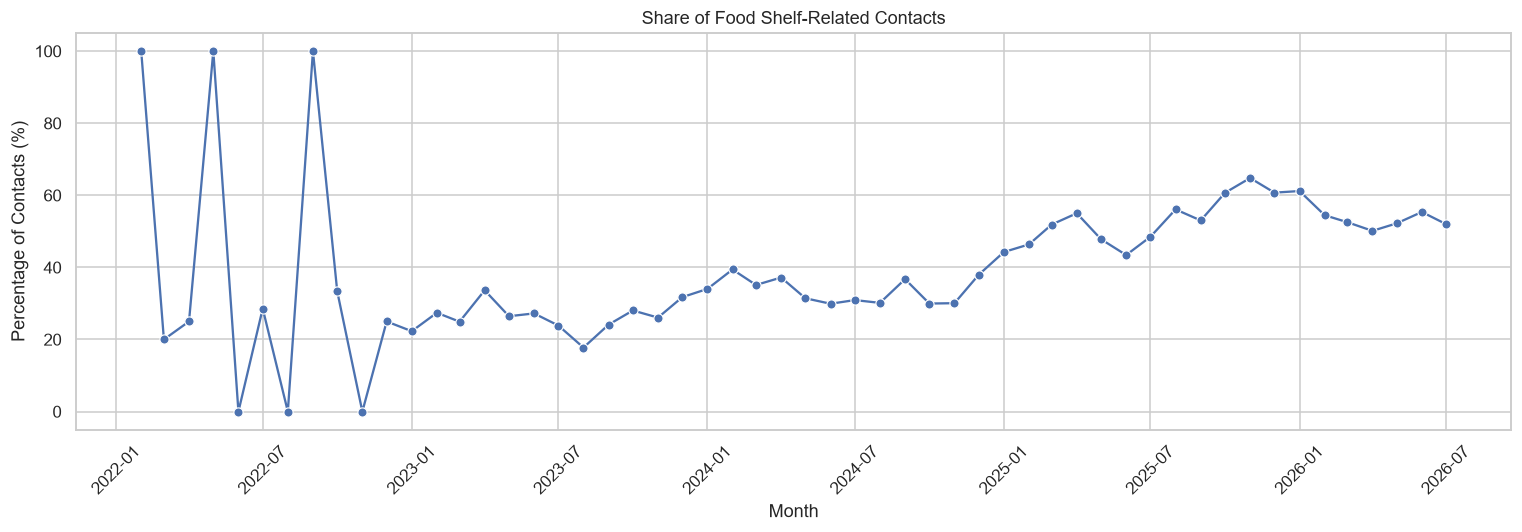

In [49]:
# Aggregate contacts by month
food_shelf_monthly = (
    df.dropna(subset=["contact_date"])
    .set_index("contact_date")
    .resample("MS")
    .agg(
        all_contacts=("__ID", "size"),
        food_shelf_related=("food_shelf_related", "sum")
    )
)

# Calculate share of all contacts
food_shelf_monthly["food_shelf_share"] = (
    food_shelf_monthly["food_shelf_related"]
    / food_shelf_monthly["all_contacts"]
    * 100
)

display(food_shelf_monthly.tail(12))

# Plot percentage over time
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=food_shelf_monthly.reset_index(),
    x="contact_date",
    y="food_shelf_share",
    marker="o"
)

plt.title("Share of Food Shelf-Related Contacts")
plt.xlabel("Month")
plt.ylabel("Percentage of Contacts (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Contacts
FollowUpNeeded,
<NA>,35725
Other,13542
2 Weeks,362
1 Day,86
6 Weeks,8
2 Days,3


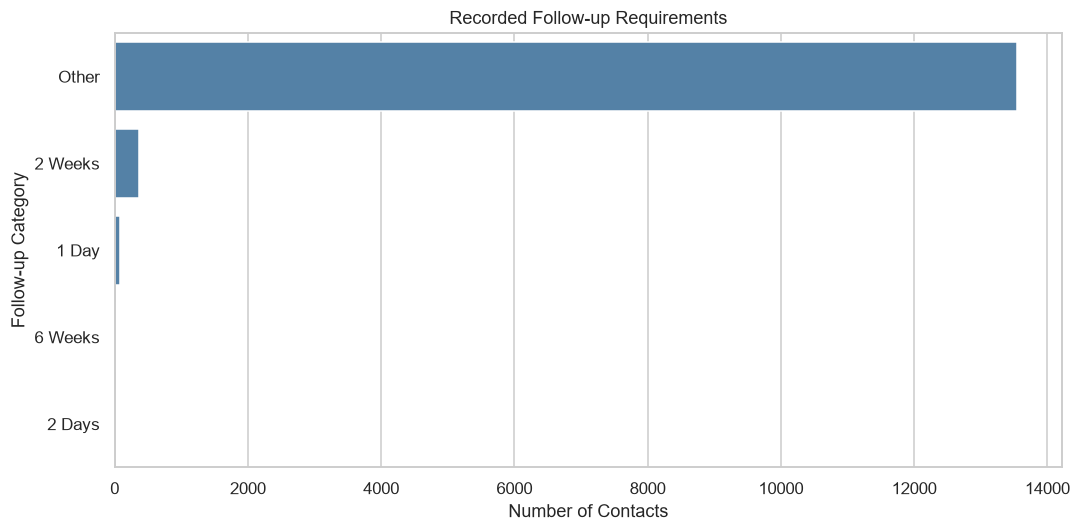

In [50]:
# Examine recorded follow-up requirements
followup_counts = (
    df["FollowUpNeeded"]
    .value_counts(dropna=False)
)

display(
    followup_counts.to_frame("Contacts")
)

# Plot follow-up categories
plt.figure(figsize=(10, 5))

sns.barplot(
    x=followup_counts.values,
    y=followup_counts.index.astype(str),
    color="steelblue"
)

plt.title("Recorded Follow-up Requirements")
plt.xlabel("Number of Contacts")
plt.ylabel("Follow-up Category")

plt.tight_layout()
plt.show()


In [51]:
# Identify records with a follow-up category
df["followup_recorded"] = (
    df["FollowUpNeeded"].notna()
)

# Check explicit completion flag
df["first_followup_complete"] = (
    pd.to_numeric(
        df["isFollowup1Complete"],
        errors="coerce"
    ).eq(1)
)

followup_subset = df[
    df["followup_recorded"]
].copy()

print(
    "Records with follow-up category:",
    len(followup_subset)
)

print(
    "First follow-ups explicitly completed:",
    followup_subset["first_followup_complete"].sum()
)

print(
    "Percentage marked complete:",
    round(
        followup_subset["first_followup_complete"].mean() * 100,
        2
    )
)


Records with follow-up category: 14001
First follow-ups explicitly completed: 13934
Percentage marked complete: 99.52


count   49,709.00
mean         1.22
std          0.77
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         14.00
Name: household_size, dtype: float64

Records outside expected range: 59


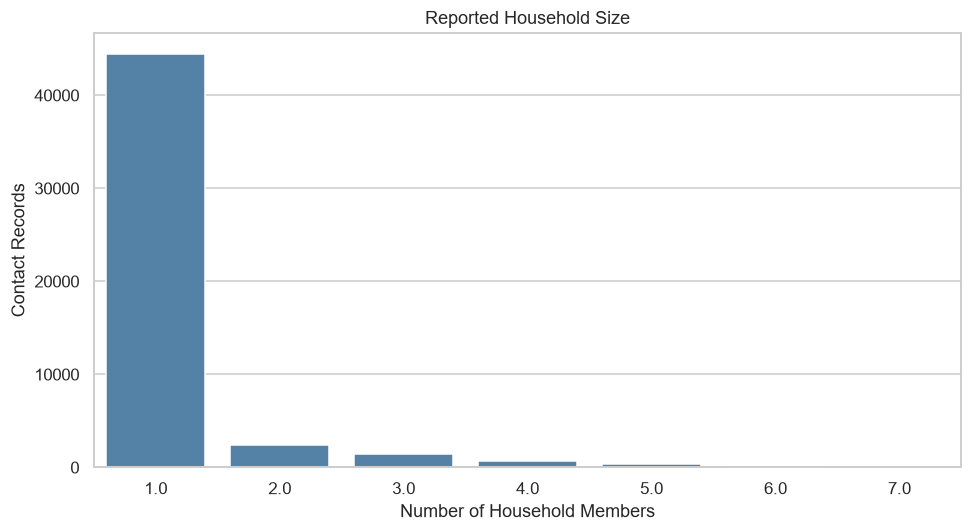

In [52]:
# Convert household size to numeric
df["household_size"] = pd.to_numeric(
    df["NumberInHouse"],
    errors="coerce"
)

# Examine summary statistics
display(
    df["household_size"].describe()
)

# Flag values outside the dictionary's expected range
household_outliers = df[
    df["household_size"].notna()
    & (
        (df["household_size"] < 1)
        | (df["household_size"] > 7)
    )
]

print(
    "Records outside expected range:",
    len(household_outliers)
)

# Distribution for values from 1 to 7
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df[
        df["household_size"].between(1, 7)
    ],
    x="household_size",
    color="steelblue"
)

plt.title("Reported Household Size")
plt.xlabel("Number of Household Members")
plt.ylabel("Contact Records")

plt.tight_layout()
plt.show()

,County,Region,SNAP Status,CallLength,Call Answered,ReferralInfoEntry,Referral Source
CallMethod,,,,,,,
Chat,56.95,56.95,50.27,40.64,91.71,32.62,100.00
Chat Ticket,82.16,82.25,74.05,89.31,89.22,36.45,100.00
Email,12.83,13.93,60.10,67.25,71.02,19.34,99.81
Live Call,40.62,40.97,40.10,20.68,89.56,16.68,100.00
Partner Referral,6.36,7.27,16.36,69.09,13.64,27.27,20.00
SNAP Rx,6.60,6.86,0.04,58.92,0.02,35.30,0.00
Text,62.50,63.00,74.50,53.50,91.00,25.50,100.00
Voice Mail,69.46,69.63,59.60,35.01,36.31,48.73,100.00


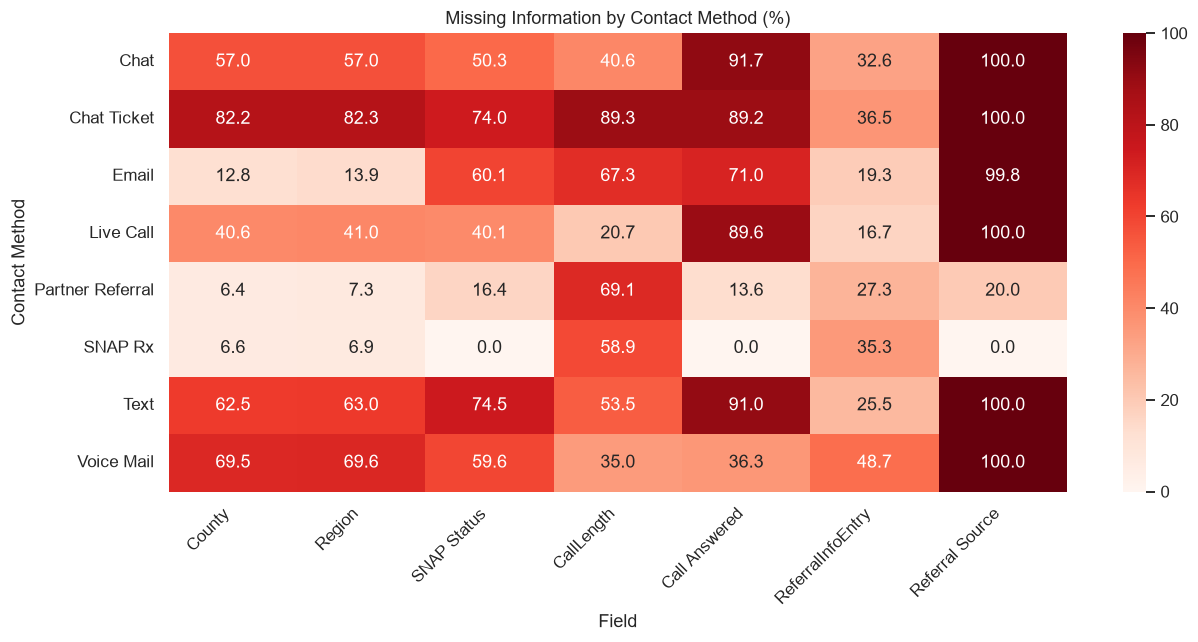

In [53]:
# Select fields to compare
fields_to_check = [
    "County",
    "Region",
    "SNAP Status",
    "CallLength",
    "Call Answered",
    "ReferralInfoEntry",
    "Referral Source"
]

# Calculate missing percentages by contact method
missing_by_method = (
    df.groupby("CallMethod")[fields_to_check]
    .apply(
        lambda group: group.isna().mean() * 100
    )
)

display(missing_by_method.round(2))

# Heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    missing_by_method,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    vmin=0,
    vmax=100
)

plt.title("Missing Information by Contact Method (%)")
plt.xlabel("Field")
plt.ylabel("Contact Method")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [54]:
missing_by_year = (
    df.groupby("year")[fields_to_check]
    .apply(
        lambda group: group.isna().mean() * 100
    )
)

display(missing_by_year.round(2))

,County,Region,SNAP Status,CallLength,Call Answered,ReferralInfoEntry,Referral Source
year,,,,,,,
2022,75.61,75.61,9.76,100.00,0.00,46.34,0.00
2023,45.38,45.89,35.20,55.70,53.59,31.62,74.24
2024,30.19,30.74,33.56,26.65,51.50,29.91,68.83
2025,19.38,19.40,22.60,44.65,33.67,27.49,47.48
2026,18.08,18.22,25.72,47.48,37.41,26.69,43.20


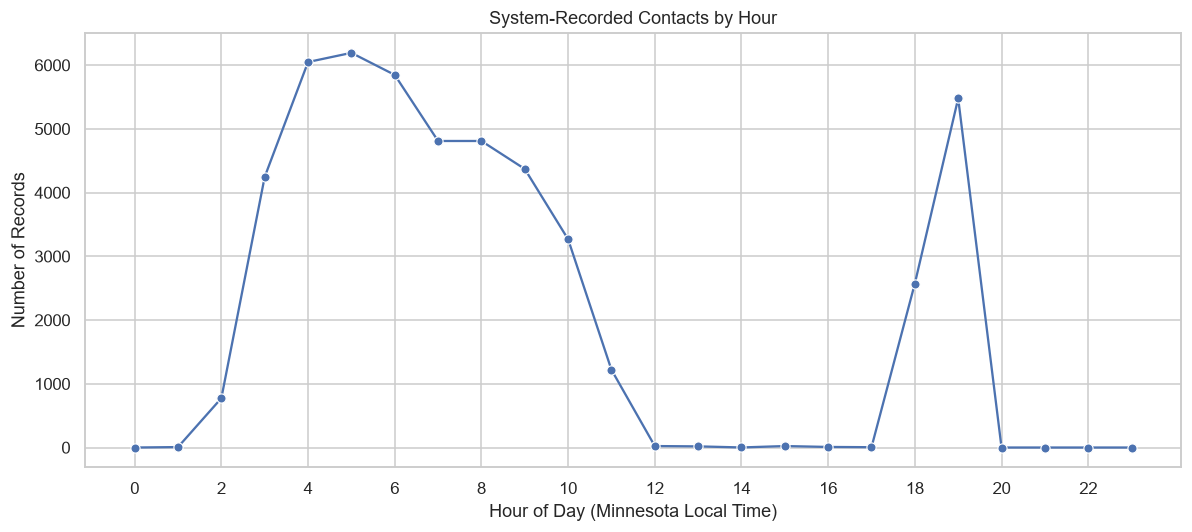

In [55]:
# Convert UTC timestamps to Minnesota local time
df["timestamp_local"] = (
    df["event_timestamp_utc"]
    .dt.tz_convert("America/Chicago")
)

# Extract hour
df["contact_hour"] = (
    df["timestamp_local"].dt.hour
)

# Count records by hour
hourly_contacts = (
    df.groupby("contact_hour")
    .size()
    .reindex(range(24), fill_value=0)
)

# Plot
plt.figure(figsize=(11, 5))

sns.lineplot(
    x=hourly_contacts.index,
    y=hourly_contacts.values,
    marker="o"
)

plt.title("System-Recorded Contacts by Hour")
plt.xlabel("Hour of Day (Minnesota Local Time)")
plt.ylabel("Number of Records")

plt.xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

In [56]:
# Create output directories
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Export monthly contact counts
monthly_contacts.to_csv(
    OUTPUT_DIR / "incoming_call_monthly_counts.csv",
    index=False
)

# 2. Export contact method counts
method_counts.to_csv(
    OUTPUT_DIR / "incoming_call_method_counts.csv",
    index=False
)

# 3. Export reason counts
reason_counts.to_csv(
    OUTPUT_DIR / "incoming_call_reason_counts.csv",
    index=False
)

# 4. Export missing-value summary
missing_summary.to_csv(
    OUTPUT_DIR / "incoming_call_missing_values.csv"
)

# 5. Prepare county-month aggregate data
county_month = (
    df.dropna(
        subset=["county_for_analysis", "contact_date"]
    )
    .groupby(
        ["year_month", "county_for_analysis"]
    )
    .size()
    .reset_index(name="contacts")
)

# Convert period to string for CSV compatibility
county_month["year_month"] = (
    county_month["year_month"].astype(str)
)

# Export county-month counts
county_month.to_csv(
    OUTPUT_DIR / "incoming_call_county_month.csv",
    index=False
)

print("EDA summaries exported successfully.")
print("Output directory:", OUTPUT_DIR.resolve())

EDA summaries exported successfully.
Output directory: C:\Users\vasquema\Documents\GitHub\minnemudac-insight-team\outputs
